In [1]:
import pandas as pd
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import datetime
import QuantLib as ql


In [2]:
eval_date = ql.Date(19, 5, 2026)
calendar = ql.UnitedStates(ql.UnitedStates.NYSE)
day_count = ql.Actual365Fixed()
compounding = ql.Continuous

ql.Settings.instance().evaluationDate = eval_date


In [3]:
fwd_rate = ql.SimpleQuote(0.03)
zero_curve = ql.FlatForward(eval_date, ql.QuoteHandle(fwd_rate), day_count, compounding)
zero_curve_handle = ql.YieldTermStructureHandle(zero_curve)

spot_price = 295.7
spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot_price))

div_pillars = [
    ql.Date(21, 5, 2026),
    ql.Date(19, 6, 2026),
    ql.Date(18, 9, 2026),
    ql.Date(17, 12, 2026)
]

div_curve = ql.ZeroCurve(
    div_pillars, 
    [0.0, 0.10358, 0.07464, 0.05098], 
    day_count, 
    calendar
)

div_curve.enableExtrapolation()
div_curve_handle = ql.YieldTermStructureHandle(div_curve)

vol_expiry_dates = [
    ql.Date(19, 8, 2026),
    ql.Date(19, 11, 2026),
    ql.Date(19, 2, 2027),
    ql.Date(19, 5, 2027),
    ql.Date(19, 8, 2027),
    ql.Date(19, 11, 2027),
    ql.Date(19, 2, 2028),
    ql.Date(19, 5, 2028)
]

atm_vols = [0.324566, 0.324566, 0.320002, 0.314524, 0.309046, 0.310071, 0.310603, 0.310603]

atm_vol_curve = ql.BlackVarianceCurve(
    eval_date, 
    vol_expiry_dates, 
    atm_vols, 
    day_count
)

atm_vol_handle = ql.BlackVolTermStructureHandle(atm_vol_curve)


In [4]:
bsm_process = ql.BlackScholesMertonProcess(
    spot_handle, 
    div_curve_handle, 
    zero_curve_handle, 
    atm_vol_handle
)


In [5]:
print(f"{'Tenor':<12} {'Expiry':<20} {'ATM Vol':>10} {'Variance':>12}")
print("-" * 57)

test_dates = vol_expiry_dates + [ql.Date(19, 8, 2028)]  # Include 5Y extrapolation

for d in test_dates:
    t = day_count.yearFraction(eval_date, d)
    vol = atm_vol_curve.blackVol(d, spot_price, True)        # ATM strike = spot
    var = atm_vol_curve.blackVariance(d, spot_price, True)
    print(f"{t:<12.4f} {str(d):<20} {vol:>10.4f} {var:>12.6f}")
    

Tenor        Expiry                  ATM Vol     Variance
---------------------------------------------------------
0.2521       August 19th, 2026        0.3246     0.026552
0.5041       November 19th, 2026      0.3246     0.053104
0.7562       February 19th, 2027      0.3200     0.077432
1.0000       May 19th, 2027           0.3145     0.098925
1.2521       August 19th, 2027        0.3090     0.119583
1.5041       November 19th, 2027      0.3101     0.144611
1.7562       February 19th, 2028      0.3106     0.169425
2.0027       May 19th, 2028           0.3106     0.193213
2.2548       August 19th, 2028        0.3106     0.217530


In [8]:
mc_process = ql.GeneralizedBlackScholesProcess(
    spot_handle, 
    div_curve_handle, 
    zero_curve_handle, 
    atm_vol_handle
)

sim_dates = [
    ql.Date(19, 6, 2026),
    ql.Date(18, 9, 2026),
    ql.Date(17, 12, 2026),
    ql.Date(19, 2, 2027),
    ql.Date(19, 5, 2027),
    ql.Date(19, 8, 2027),
    ql.Date(19, 11, 2027),
    ql.Date(19, 2, 2028),
    ql.Date(19, 5, 2028)
]

sim_times = [day_count.yearFraction(eval_date, d) for d in sim_dates]
time_grid = ql.TimeGrid(sim_times, len(sim_times))


In [ ]:
n_steps = len(time_grid) - 1

sobol_urng = ql.UniformLowDiscrepancySequenceGenerator(    
    n_steps,
    0,
    ql.SobolRsg.JoeKuoD7
)

gaussian_rng = ql.GaussianLowDiscrepancySequenceGenerator(sobol_urng)

path_gen = ql.GaussianSobolPathGenerator(
    mc_process, 
    time_grid, 
    gaussian_rng, 
    True
)


In [29]:
n_paths = 2 ** 10

paths = np.zeros((n_paths, n_steps + 1))

for i in range(n_paths):
    sample = path_gen.next()   # advances Sobol by 1 sequence
    path   = sample.value()          # ql.Path object
    paths[i] = [path[j] for j in range(n_steps + 1)]

# ─── Inspect ─────────────────────────────────────────────────────────
print(f"paths.shape : {paths.shape}")   # (1024, 10)
print(f"paths[0]    : {np.round(paths[0], 4)}")  # first path, t0..t9
print(f"All start at S0={spot_price}: {np.allclose(paths[:, 0], spot_price)}")


paths.shape : (1024, 10)
paths[0]    : [295.7    292.562  286.2871 283.4988 282.8022 282.124  281.6443 280.5516
 279.4932 278.5293]
All start at S0=295.7: True


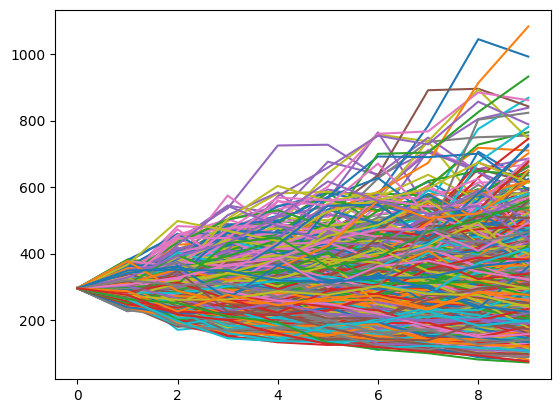

In [33]:
plt.plot(paths.T)
plt.show()
